In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 Classroom
'Colab Notebooks'
'cousera certificate1.pdf'
 download_copy.pdf
'DV ASSIGNMENT 1 SNEHA MESTRI- 42.pdf'
'government details .pdf'
'LOR sneha .pdf'
'Resized pictures - 1'
'Resized pictures - 1 (1)'
'Resized pictures - 1 (2)'
'Sahil Kanse-Resume-1.pdf'
 sneha.jpg
'Sneha Mestri certificate google cloud.pdf'
'SNEHA-MESTRI-Participant-Certificate (1) (1).pdf'
'SNEHA-MESTRI-Participant-Certificate (1).pdf'
'SNEHA-MESTRI-Participant-Certificate (2).pdf'
 Sneha-Mestri-Python-3.4.3-Participant-Test-Certificate.pdf
 stressdata.zip
'vocational 2024.pdf'
'VOCATIONAL CERTIFICATE.pdf'


In [ ]:
!unzip /content/drive/MyDrive/stressdata.zip -d /content/stressdata

Archive:  /content/drive/MyDrive/stressdata.zip
   creating: /content/stressdata/S11/
  inflating: /content/stressdata/S11/S14.pkl  
   creating: /content/stressdata/S12/
  inflating: /content/stressdata/S12/S15.pkl  
   creating: /content/stressdata/S13/
  inflating: /content/stressdata/S13/S16.pkl  
   creating: /content/stressdata/S14/
  inflating: /content/stressdata/S14/S17.pkl  
   creating: /content/stressdata/S1/
  inflating: /content/stressdata/S1/S3.pkl  
   creating: /content/stressdata/S2/
  inflating: /content/stressdata/S2/S4.pkl  
   creating: /content/stressdata/S3/
  inflating: /content/stressdata/S3/S5.pkl  
   creating: /content/stressdata/S4/
  inflating: /content/stressdata/S4/S6.pkl  
   creating: /content/stressdata/S5/
  inflating: /content/stressdata/S5/S7.pkl  
   creating: /content/stressdata/S6/
  inflating: /content/stressdata/S6/S8.pkl  
   creating: /content/stressdata/S7/
  inflating: /content/stressdata/S7/S9.pkl  
   creating: /content/stressdata/S8/
 

In [ ]:
!ls /content/stressdata

S1  S10  S11  S12  S13	S14  S2  S3  S4  S5  S6  S7  S8  S9


In [ ]:
BASE_PATH = "/content/stressdata"

In [ ]:
!ls /content/stressdata/S8

S10.pkl


In [ ]:
import os

# Find where .pkl files are
for root, dirs, files in os.walk("/content/stressdata"):
    for f in files:
        if f.endswith(".pkl"):
            print("Found sample file at:", os.path.join(root, f))
            BASE_PATH = os.path.dirname(os.path.dirname(os.path.join(root, f)))
            break
    else:
        continue
    break

print("Using BASE_PATH:", BASE_PATH)

Found sample file at: /content/stressdata/S13/S16.pkl
Using BASE_PATH: /content/stressdata


In [ ]:
!find /content/stressdata -name "*.pkl"

/content/stressdata/S13/S16.pkl
/content/stressdata/S2/S4.pkl
/content/stressdata/S7/S9.pkl
/content/stressdata/S9/S11.pkl
/content/stressdata/S1/S3.pkl
/content/stressdata/S11/S14.pkl
/content/stressdata/S6/S8.pkl
/content/stressdata/S14/S17.pkl
/content/stressdata/S5/S7.pkl
/content/stressdata/S3/S5.pkl
/content/stressdata/S4/S6.pkl
/content/stressdata/S8/S10.pkl
/content/stressdata/S12/S15.pkl
/content/stressdata/S10/S13.pkl


In [ ]:
import pickle
import numpy as np
import os

all_data_X = []
all_data_y = []

# BASE_PATH is already defined from a previous cell as "/content/stressdata"
for root, _, files in os.walk(BASE_PATH):
    for file in files:
        if file.endswith(".pkl"):
            file_path = os.path.join(root, file)
            print(f"Loading {file_path}")
            with open(file_path, 'rb') as f:
                subject_data = pickle.load(f, encoding='latin1') # Use latin1 for python2 pickle files

            # Extract ACC, BVP, EDA from wrist sensor
            acc = subject_data['signal']['wrist']['ACC']
            bvp = subject_data['signal']['wrist']['BVP']
            eda = subject_data['signal']['wrist']['EDA']

            # Ensure all data has the same number of samples along the first axis
            min_len = min(len(acc), len(bvp), len(eda))

            # Truncate to the minimum length
            acc = acc[:min_len]
            bvp = bvp[:min_len]
            eda = eda[:min_len]

            # Concatenate features: ACCx, ACCy, ACCz, EDA, BVP
            # Reshape BVP and EDA to (min_len, 1) if they are (min_len,) from 1D array
            if bvp.ndim == 1:
                bvp = bvp.reshape(-1, 1)
            if eda.ndim == 1:
                eda = eda.reshape(-1, 1)

            X_subject = np.hstack((acc, eda, bvp))

            # Extract labels
            y_subject = subject_data['label'][:min_len] # Also truncate labels

            all_data_X.append(X_subject)
            all_data_y.append(y_subject)

X_all = np.vstack(all_data_X) if all_data_X else np.array([])
y_all = np.hstack(all_data_y) if all_data_y else np.array([])

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")


Loading /content/stressdata/S13/S16.pkl
Loading /content/stressdata/S2/S4.pkl
Loading /content/stressdata/S7/S9.pkl
Loading /content/stressdata/S9/S11.pkl
Loading /content/stressdata/S1/S3.pkl
Loading /content/stressdata/S11/S14.pkl
Loading /content/stressdata/S6/S8.pkl
Loading /content/stressdata/S14/S17.pkl
Loading /content/stressdata/S5/S7.pkl
Loading /content/stressdata/S3/S5.pkl
Loading /content/stressdata/S4/S6.pkl
Loading /content/stressdata/S8/S10.pkl
Loading /content/stressdata/S12/S15.pkl
Loading /content/stressdata/S10/S13.pkl
X_all shape: (323156, 5)
y_all shape: (323156,)


In [ ]:
# Normal = everything except stress
normal_mask = y_all != 1

X_normal = X_all[normal_mask]

print("Normal samples:", X_normal.shape)

Normal samples: (319301, 5)


In [ ]:
WINDOW_SIZE = 128
STEP_SIZE = 128

X_win = []

for i in range(0, len(X_normal) - WINDOW_SIZE, STEP_SIZE):
    X_win.append(X_normal[i:i+WINDOW_SIZE])

X_win = np.array(X_win)

print("Windowed normal data:", X_win.shape)

Windowed normal data: (2494, 128, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_win = scaler.fit_transform(
    X_win.reshape(-1, X_win.shape[-1])
).reshape(X_win.shape)

In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(10,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

# Example dataset
X_train = np.random.rand(500,10)
y_train = np.random.randint(0,2,500)

model.fit(X_train, y_train, epochs=20)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.4798 - loss: 0.6991
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5158 - loss: 0.6936
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4772 - loss: 0.6975
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5183 - loss: 0.6936 
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5852 - loss: 0.6879 
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5398 - loss: 0.6927 
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5383 - loss: 0.6904 
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5154 - loss: 0.6934 
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5337 - loss: 0.6935 
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5428 - loss: 0.6897 
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5553 - loss: 0.6867 
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.

In [ ]:
def representative_dataset():
    for i in range(100):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

Saved artifact at '/tmp/tmpw74a94e6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133335214340816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133335214341584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133335214339856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133335214338512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133335214339472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133335214340624: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
with open("stress_model.tflite", "wb") as f:
    f.write(tflite_model)

In [ ]:
with open("stress_model.tflite","rb") as f:
    model_bytes = f.read()

with open("stress_autoencoder.h","w") as f:
    f.write("const unsigned char stress_autoencoder_tflite[] = {")
    f.write(",".join(str(b) for b in model_bytes))
    f.write("};")

In [ ]:
from google.colab import files
files.download("stress_autoencoder.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
history = autoencoder.fit(
    X_win, X_win,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 925ms/step - loss: 1.3866 - val_loss: 0.9628
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 1.3681 - val_loss: 18.8312
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.5963 - val_loss: 0.9079
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.5928 - val_loss: 0.8842
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 1.3445 - val_loss: 0.8875
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.5738 - val_loss: 0.9409
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.6038 - val_loss: 0.9121
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: nan - val_loss: nan
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: nan - val_loss: nan


In [ ]:
# Apply autoencoder to ALL data
X_all_win = []

for i in range(0, len(X_all) - WINDOW_SIZE, STEP_SIZE):
    X_all_win.append(X_all[i:i+WINDOW_SIZE])

X_all_win = np.array(X_all_win)

X_all_win = scaler.transform(
    X_all_win.reshape(-1, X_all_win.shape[-1])
).reshape(X_all_win.shape)

reconstructions = autoencoder.predict(X_all_win)

recon_error = np.mean(
    np.square(X_all_win - reconstructions),
    axis=(1,2)
)

print("Reconstruction error shape:", recon_error.shape)

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step
Reconstruction error shape: (2524,)


In [ ]:
threshold = np.percentile(recon_error, 90)

stress_pred = (recon_error > threshold).astype(int)

In [ ]:
y_true = []

for i in range(0, len(y_all) - WINDOW_SIZE, STEP_SIZE):
    # Stress if majority of window is stress (label == 1)
    y_true.append(int(np.mean(y_all[i:i+WINDOW_SIZE]) == 1))

y_true = np.array(y_true)

print("True label distribution:", np.bincount(y_true))

True label distribution: [2495   29]


In [ ]:
threshold = np.percentile(recon_error, 93)

In [ ]:
y_pred = (recon_error > threshold).astype(int)

print("Predicted label distribution:", np.bincount(y_pred))

Predicted label distribution: [2347  177]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print(f"Autoencoder Stress Accuracy: {accuracy * 100:.2f}%")

Autoencoder Stress Accuracy: 91.84%


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[2318  177]
 [  29    0]]
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2495
           1       0.00      0.00      0.00        29

    accuracy                           0.92      2524
   macro avg       0.49      0.46      0.48      2524
weighted avg       0.98      0.92      0.95      2524



In [ ]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC (original):", roc_auc_score(y_true, recon_error))
print("ROC-AUC (inverted):", roc_auc_score(y_true, -recon_error))

ROC-AUC (original): 0.2634786815009329
ROC-AUC (inverted): 0.7365213184990671


In [ ]:
import numpy as np

# Smooth predicted labels using majority vote over 3 windows
y_pred_smooth = np.convolve(y_pred, np.ones(3)/3, mode='same')
y_pred_smooth = (y_pred_smooth > 0.5).astype(int)

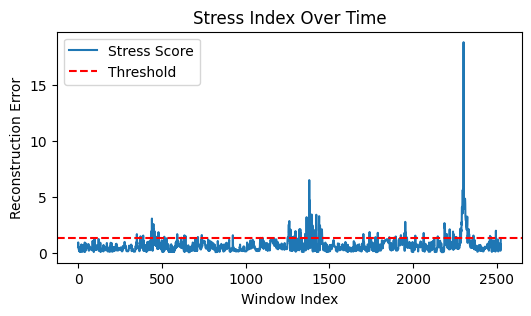

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.plot(recon_error, label="Stress Score")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.title("Stress Index Over Time")
plt.xlabel("Window Index")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()

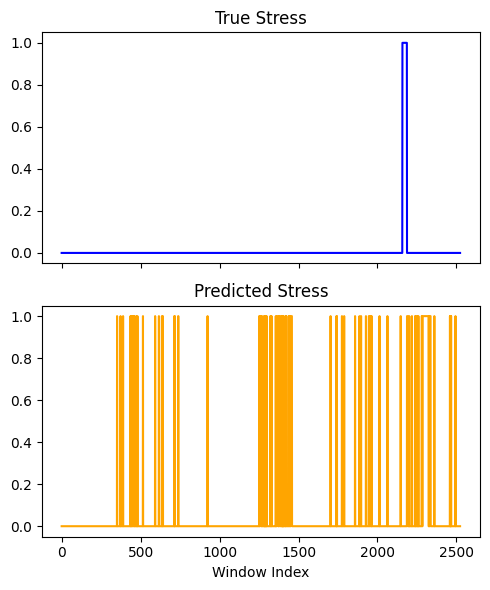

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(5,6), sharex=True)

ax[0].plot(y_true, color='blue')
ax[0].set_title("True Stress")

ax[1].plot(y_pred, color='orange')
ax[1].set_title("Predicted Stress")

ax[1].set_xlabel("Window Index")
plt.tight_layout()
plt.show()

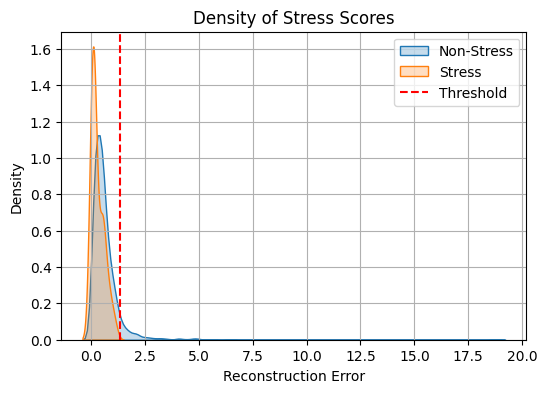

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.kdeplot(
    recon_error[y_true == 0],
    label="Non-Stress",
    fill=True
)

sns.kdeplot(
    recon_error[y_true == 1],
    label="Stress",
    fill=True
)

plt.axvline(threshold, color='red', linestyle='--', label="Threshold")

plt.title("Density of Stress Scores")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

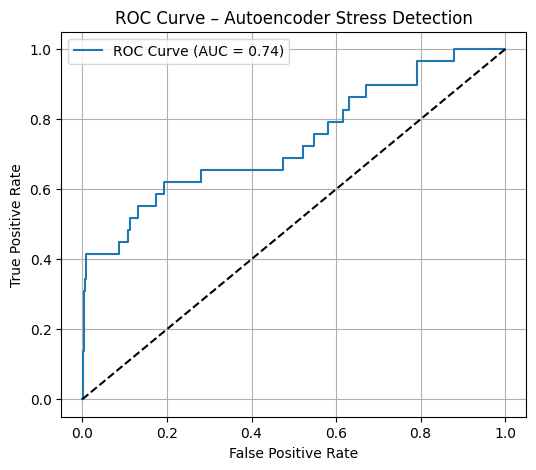

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, -recon_error)  # inverted score
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Autoencoder Stress Detection")
plt.legend()
plt.grid(True)
plt.show()

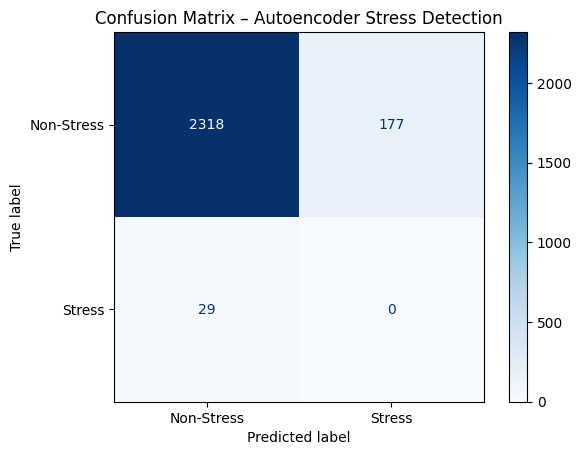

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Stress", "Stress"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Autoencoder Stress Detection")
plt.show()

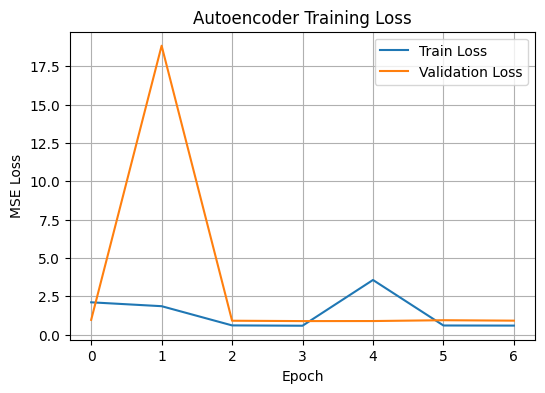

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
autoencoder.save("stress_autoencoder.h5")

In [ ]:
import tensorflow as tf
import numpy as np

def representative_dataset():
    for i in range(100):
        yield [X_win[i:i+1].astype(np.float32)]

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(autoencoder)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Apply the suggested fix from the error message
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.SELECT_TF_OPS # Allow TensorFlow operations
]
converter._experimental_lower_tensor_list_ops = False # Disable experimental tensor list lowering

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# It's good practice to save the model in the native Keras format first
# autoencoder.save("stress_autoencoder.keras") # This was previously done with .h5, saving as .keras is newer best practice

Saved artifact at '/tmp/tmp_7wsywwr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 5), dtype=tf.float32, name='keras_tensor_378')
Output Type:
  TensorSpec(shape=(None, 128, 5), dtype=tf.float32, name=None)
Captures:
  136211790755216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790755024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790756560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790751952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790756944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790754640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790755792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136211790756176: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
with open("stress_autoencoder.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

TFLite model saved!


In [ ]:
!xxd -i stress_autoencoder.tflite > stress_autoencoder.h

In [ ]:
from google.colab import files
files.download("stress_autoencoder.h")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>